In [ ]:
# SPDX-License-Identifier: MIT


In [1]:
import os
import sys
import time
import yaml

current_dir = os.getcwd()
repo_root = os.path.abspath(os.path.join(current_dir, '..'))

if repo_root not in sys.path:
    sys.path.append(repo_root)


import spx_python

# 1) Connect to the running SPX Server
client = spx_python.init(
    address="http://localhost:8000",
    product_key=os.environ.get("SPX_PRODUCT_KEY", "")  # required env var
)

# 2) Define the model (PT100-like sensor) + Modbus TCP mapping
pt_100_yaml = '''
attributes:
  temperature: 25.0
  sensor_fault: 0
actions:
  - { ramp: $in(temperature), stop_value: 150, duration: 5, type: overshoot, overshoot: 5}
  - { noise: $out(temperature), std: 0.01, mode: proportional}
communication:
  - modbus_tcp:
      poll_interval: 1.00
      mapping:
        temperature: {address: [0,1], group: h_r, type: uint_32}
        sensor_fault: { address: [4,4], group: c_o, type: uint_16 }
'''
# 3) Register the model and create an instance
model_def = yaml.safe_load(pt_100_yaml)
client["models"]["pt_100_modbus"] = model_def
client["instances"]["pt100_mb_1"] = "pt_100_modbus"
model = client["instances"]["pt100_mb_1"]
print("Instance created:", model)

Instance created: {
  "name": "pt100_mb_1",
  "attr": {
    "definition": {
      "type": "dict",
      "value": {}
    },
    "destroyed": {
      "type": "bool",
      "value": false,
      "is_property": true,
      "has_setter": false
    },
    "enabled": {
      "type": "bool",
      "value": true,
      "is_property": true,
      "has_setter": true
    },
    "hooks": {
      "type": "dict",
      "value": {}
    },
    "logger": {
      "type": "Logger",
      "value": "<non-serializable: Logger>"
    },
    "name": {
      "type": "str",
      "value": "pt100_mb_1"
    },
    "parent": {
      "type": "NoneType",
      "value": null
    },
    "state": {
      "type": "SpxComponentState",
      "value": "INITIALIZED"
    },
    "uid": {
      "type": "str",
      "value": "405efbef-69b5-4839-9f9d-8f9e57b0ca5d"
    }
  },
  "children": [
    {
      "name": "attributes",
      "attr": {
        "definition": {
          "type": "dict",
          "value": {}
        },
        "

Time: 0.0s, Temp: 0.00, Fault: 0, Model Temp: 0.00, Model Time: 0.00s
Time: 0.1s, Temp: 0.03, Fault: 0, Model Temp: 3.48, Model Time: 0.10s
Time: 0.2s, Temp: 0.06, Fault: 0, Model Temp: 6.97, Model Time: 0.20s
Time: 0.3s, Temp: 0.10, Fault: 0, Model Temp: 10.45, Model Time: 0.30s
Time: 0.4s, Temp: 0.13, Fault: 0, Model Temp: 13.93, Model Time: 0.40s
Time: 0.5s, Temp: 0.17, Fault: 0, Model Temp: 17.40, Model Time: 0.50s
Time: 0.6s, Temp: 0.20, Fault: 0, Model Temp: 20.86, Model Time: 0.60s
Time: 0.7s, Temp: 0.24, Fault: 0, Model Temp: 24.32, Model Time: 0.70s
Time: 0.8s, Temp: 0.27, Fault: 0, Model Temp: 27.78, Model Time: 0.80s
Time: 0.9s, Temp: 0.31, Fault: 0, Model Temp: 31.22, Model Time: 0.90s
Time: 1.0s, Temp: 0.34, Fault: 0, Model Temp: 34.65, Model Time: 1.00s
Time: 1.1s, Temp: 0.38, Fault: 0, Model Temp: 38.07, Model Time: 1.10s
Time: 1.2s, Temp: 0.41, Fault: 0, Model Temp: 41.48, Model Time: 1.20s
Time: 1.3s, Temp: 0.44, Fault: 0, Model Temp: 44.87, Model Time: 1.30s
Time: 1.4

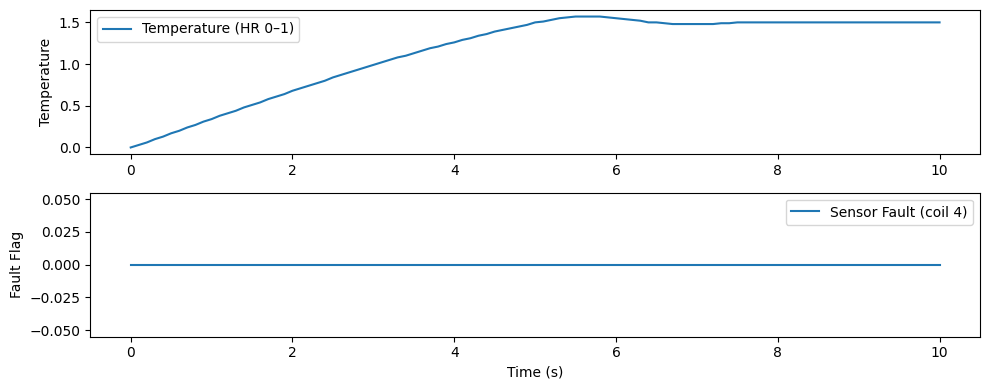

In [26]:
import os
import time
import matplotlib.pyplot as plt

from modbus_tk import modbus_tcp
from modbus_tk import defines as c


class SUTSensor:
    """Software Under Test (SUT): thin Modbus TCP wrapper for reading measurements.
    Hides protocol details from the test/plotting logic.
    """
    def __init__(self, host="127.0.0.1", port=502, unit=1, scale=100.0, timeout=2.0):
        self.host = host
        self.port = port
        self.unit = unit
        self.scale = scale
        self.timeout = timeout
        self._mb = None

    def connect(self):
        """Create master and validate connectivity with a lightweight probe."""
        self._mb = modbus_tcp.TcpMaster(host=self.host, port=self.port)
        self._mb.set_timeout(self.timeout)
        # # Optional: do a tiny probe read; if server rejects, this will raise.
        # try:
        #     # A harmless probe: read 0 registers (some stacks allow count=0, others do not).
        #     # If your server dislikes count=0, you can skip the probe or read a known-safe address.
        #     self._mb.execute(self.unit, c.READ_COILS, 0, 1)
        # except Exception as e:
        #     raise RuntimeError(f"Could not connect to Modbus server at {self.host}:{self.port} (unit {self.unit})") from e

    @staticmethod
    def _u32_from_two_u16_be(regs):
        """Combine two 16-bit registers into one 32-bit unsigned integer (Big Endian)."""
        if len(regs) != 2:
            raise ValueError(f"Expected 2 registers, got {len(regs)}")
        return ((regs[0] & 0xFFFF) << 16) | (regs[1] & 0xFFFF)

    def read_temperature_and_fault(self):
        """Temperature from HR 0–1 (uint32 Big Endian), fault flag from coil 4 (0/1)."""
        if self._mb is None:
            raise RuntimeError("Modbus master not connected. Call connect() first.")

        # Read temperature (two 16-bit holding registers)
        hr = self._mb.execute(self.unit, c.READ_HOLDING_REGISTERS, 0, 2)
        raw_u32 = self._u32_from_two_u16_be(hr)
        temp = raw_u32 / self.scale  # adjust scaling to your model if needed

        # Read fault flag (coil 4)
        coils = self._mb.execute(self.unit, c.READ_COILS, 4, 1)
        fault = int(bool(coils[0]))

        return temp, fault

    def close(self):
        """modbus_tk masters close automatically on GC; nothing required here."""
        self._mb = None

# 1) SUT: Modbus client (modbus_tk)
sensor = SUTSensor(host="127.0.0.1", port=502, unit=1, scale=100.0, timeout=2.0)
sensor.connect()

temperatures, fault_flags, timestamps = [], [], []

# 2) Start model, capture synchronously (server scheduler advances time)
model.stop()  # ensure stopped before reset
model.reset()
model.prepare()
try:
    for i in range(101):  # ~5 seconds at 0.1 s interval
        model["timer"].time = i * 0.1
        model.run()
        temp, fault = sensor.read_temperature_and_fault()
        print(f"Time: {i * 0.1:.1f}s, Temp: {temp:.2f}, Fault: {fault}, Model Temp: {model['attributes']['temperature'].internal_value:.2f}, Model Time: {model['timer'].time:.2f}s")
        temperatures.append(temp)
        fault_flags.append(fault)
        timestamps.append(i * 0.1)
        # time.sleep(0.1)  # optional: align with dt for easier inspection
finally:
    model.stop()
    sensor.close()

# 5) Plot results
plt.figure(figsize=(10, 4))
plt.subplot(2, 1, 1)
plt.plot(timestamps, temperatures, label="Temperature (HR 0–1)")
plt.ylabel("Temperature")
plt.legend()

plt.subplot(2, 1, 2)
plt.step(timestamps, fault_flags, label="Sensor Fault (coil 4)", where="post")
plt.ylabel("Fault Flag")
plt.xlabel("Time (s)")
plt.legend()
plt.tight_layout()
plt.show()

Time: 0.0s, Temp: 0.00, Fault: 0, Model Temp: 0.01, Model Time: 0.03s
Time: 0.1s, Temp: 0.00, Fault: 0, Model Temp: 3.70, Model Time: 0.15s
Time: 0.2s, Temp: 0.00, Fault: 0, Model Temp: 7.27, Model Time: 0.28s
Time: 0.3s, Temp: 0.00, Fault: 0, Model Temp: 10.98, Model Time: 0.41s
Time: 0.4s, Temp: 0.00, Fault: 0, Model Temp: 18.13, Model Time: 0.54s
Time: 0.5s, Temp: 0.00, Fault: 0, Model Temp: 21.79, Model Time: 0.67s
Time: 0.6s, Temp: 0.00, Fault: 0, Model Temp: 25.38, Model Time: 0.80s
Time: 0.7s, Temp: 0.00, Fault: 0, Model Temp: 29.00, Model Time: 0.93s
Time: 0.8s, Temp: 0.32, Fault: 0, Model Temp: 35.93, Model Time: 1.06s
Time: 0.9s, Temp: 0.32, Fault: 0, Model Temp: 39.56, Model Time: 1.20s
Time: 1.0s, Temp: 0.32, Fault: 0, Model Temp: 43.01, Model Time: 1.33s
Time: 1.1s, Temp: 0.32, Fault: 0, Model Temp: 49.98, Model Time: 1.46s
Time: 1.2s, Temp: 0.32, Fault: 0, Model Temp: 53.43, Model Time: 1.60s
Time: 1.3s, Temp: 0.32, Fault: 0, Model Temp: 56.94, Model Time: 1.73s
Time: 1.4

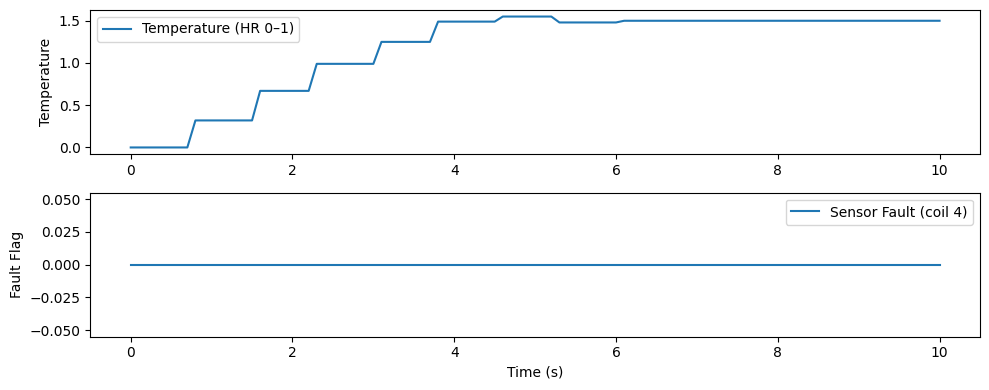

In [2]:
import os
import time
import matplotlib.pyplot as plt

from modbus_tk import modbus_tcp
from modbus_tk import defines as c


class SUTSensor:
    """Software Under Test (SUT): thin Modbus TCP wrapper for reading measurements.
    Hides protocol details from the test/plotting logic.
    """
    def __init__(self, host="127.0.0.1", port=502, unit=1, scale=100.0, timeout=2.0):
        self.host = host
        self.port = port
        self.unit = unit
        self.scale = scale
        self.timeout = timeout
        self._mb = None

    def connect(self):
        """Create master and validate connectivity with a lightweight probe."""
        self._mb = modbus_tcp.TcpMaster(host=self.host, port=self.port)
        self._mb.set_timeout(self.timeout)
        # # Optional: do a tiny probe read; if server rejects, this will raise.
        # try:
        #     # A harmless probe: read 0 registers (some stacks allow count=0, others do not).
        #     # If your server dislikes count=0, you can skip the probe or read a known-safe address.
        #     self._mb.execute(self.unit, c.READ_COILS, 0, 1)
        # except Exception as e:
        #     raise RuntimeError(f"Could not connect to Modbus server at {self.host}:{self.port} (unit {self.unit})") from e

    @staticmethod
    def _u32_from_two_u16_be(regs):
        """Combine two 16-bit registers into one 32-bit unsigned integer (Big Endian)."""
        if len(regs) != 2:
            raise ValueError(f"Expected 2 registers, got {len(regs)}")
        return ((regs[0] & 0xFFFF) << 16) | (regs[1] & 0xFFFF)

    def read_temperature_and_fault(self):
        """Temperature from HR 0–1 (uint32 Big Endian), fault flag from coil 4 (0/1)."""
        if self._mb is None:
            raise RuntimeError("Modbus master not connected. Call connect() first.")

        # Read temperature (two 16-bit holding registers)
        hr = self._mb.execute(self.unit, c.READ_HOLDING_REGISTERS, 0, 2)
        raw_u32 = self._u32_from_two_u16_be(hr)
        temp = raw_u32 / self.scale  # adjust scaling to your model if needed

        # Read fault flag (coil 4)
        coils = self._mb.execute(self.unit, c.READ_COILS, 4, 1)
        fault = int(bool(coils[0]))

        return temp, fault

    def close(self):
        """modbus_tk masters close automatically on GC; nothing required here."""
        self._mb = None

# 1) SUT: Modbus client (modbus_tk)
sensor = SUTSensor(host="127.0.0.1", port=502, unit=1, scale=100.0, timeout=2.0)
sensor.connect()

temperatures, fault_flags, timestamps = [], [], []

# 2) Start model, capture synchronously (server scheduler advances time)
model.reset()
model.prepare()
model.start()
try:
    for i in range(101):  # ~5 seconds at 0.1 s interval
        temp, fault = sensor.read_temperature_and_fault()
        print(f"Time: {i * 0.1:.1f}s, Temp: {temp:.2f}, Fault: {fault}, Model Temp: {model['attributes']['temperature'].internal_value:.2f}, Model Time: {model['timer'].time:.2f}s")
        temperatures.append(temp)
        fault_flags.append(fault)
        timestamps.append(i * 0.1)
        time.sleep(0.1)  # optional: align with dt for easier inspection
finally:
    model.stop()
    sensor.close()

# 5) Plot results
plt.figure(figsize=(10, 4))
plt.subplot(2, 1, 1)
plt.plot(timestamps, temperatures, label="Temperature (HR 0–1)")
plt.ylabel("Temperature")
plt.legend()

plt.subplot(2, 1, 2)
plt.step(timestamps, fault_flags, label="Sensor Fault (coil 4)", where="post")
plt.ylabel("Fault Flag")
plt.xlabel("Time (s)")
plt.legend()
plt.tight_layout()
plt.show()